<a href="https://colab.research.google.com/github/HafidzKurniawan/Assignment-ComputerVisionImageAnalyst/blob/main/CVL_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== TAHAP 1: UPLOAD FOTO APEL ===
Silakan unggah foto pohon apel atau kumpulan apel berwarna merah...


Saving apple1.jpg to apple1 (10).jpg

=== TAHAP 2 & 3: MEMPROSES SEGMENTASI & CCL ===
Sistem berhasil mendeteksi 47 objek apel!


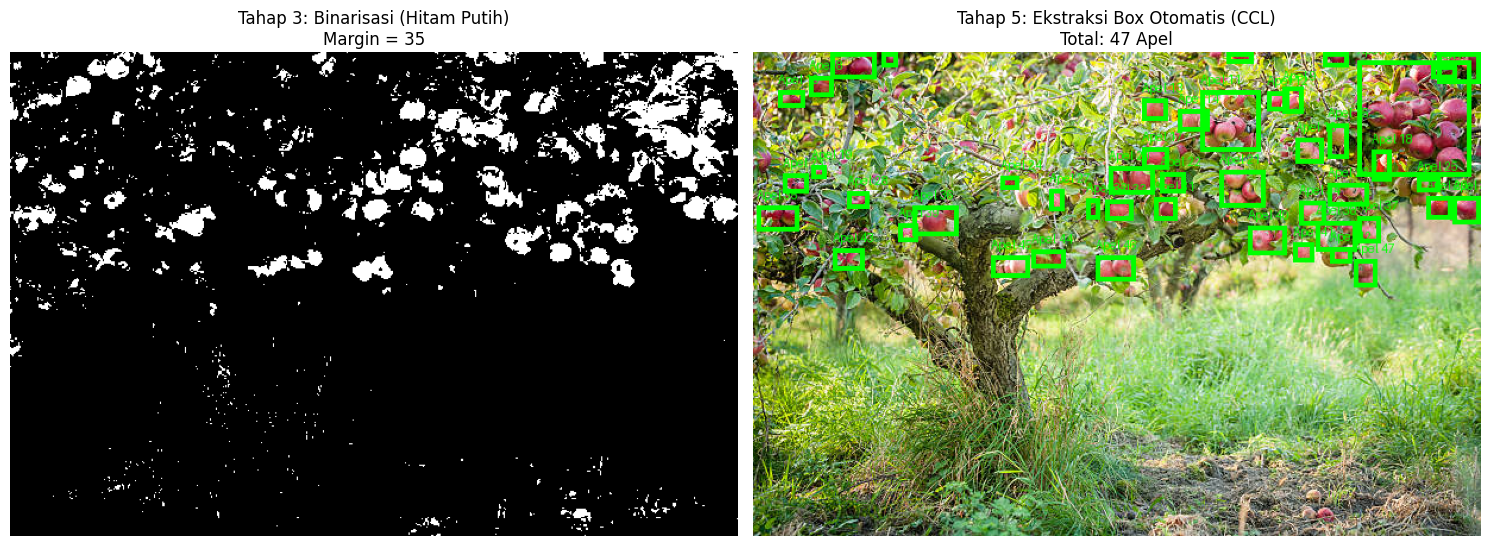

In [14]:
import numpy as np
from PIL import Image, ImageDraw
from collections import deque
from google.colab import files
import io
import matplotlib.pyplot as plt

# upload gambar
print("=== TAHAP 1: UPLOAD FOTO APEL ===")
print("Silakan unggah foto pohon apel atau kumpulan apel berwarna merah...")
uploaded = files.upload()
nama_file = list(uploaded.keys())[0]

# membaca file menjadi objek rgb
img_asli = Image.open(io.BytesIO(uploaded[nama_file])).convert('RGB')
matriks_rgb = np.array(img_asli).astype(int)

# parameter tuning
# margin: seberapa dominan warna merah dibandingkan hijau/biru (0 - 255)
MARGIN_MERAH = 35

# batas minimum ukuran objek untuk diabaikan
MIN_PIXELS = 100

# color thresholding
print("\n=== TAHAP 2 & 3: MEMPROSES SEGMENTASI & CCL ===")
R = matriks_rgb[:, :, 0]
G = matriks_rgb[:, :, 1]
B = matriks_rgb[:, :, 2]

mask = ((R > G + MARGIN_MERAH) & (R > B + MARGIN_MERAH)).astype(np.uint8)

# menelusuri hasil deteksi apel
tinggi, lebar = mask.shape
visited = np.zeros_like(mask, dtype=bool)
komponen_objek = []

# arah penelusuran piksel: Atas, Bawah, Kiri, Kanan (4-adjacency)
arah = [(-1, 0), (1, 0), (0, -1), (0, 1)]

for y in range(tinggi):
    for x in range(lebar):
        # jika menemukan piksel apel (1) yang belum pernah dikunjungi
        if mask[y, x] == 1 and not visited[y, x]:
            piksel_objek_ini = []
            queue = deque([(y, x)])
            visited[y, x] = True

            # algoritma BFS menyebar ke seluruh piksel yang bersentuhan
            while queue:
                cy, cx = queue.popleft()
                piksel_objek_ini.append((cy, cx))

                for dy, dx in arah:
                    ny, nx = cy + dy, cx + dx
                    # pastikan penelusuran tidak keluar batas gambar
                    if 0 <= ny < tinggi and 0 <= nx < lebar:
                        if mask[ny, nx] == 1 and not visited[ny, nx]:
                            visited[ny, nx] = True
                            queue.append((ny, nx))

            # simpan objek hanya jika ukurannya lebih besar dari noise yang diizinkan
            if len(piksel_objek_ini) > MIN_PIXELS:
                komponen_objek.append(piksel_objek_ini)

# visualisasi
img_hasil = img_asli.copy()
kanvas_gambar = ImageDraw.Draw(img_hasil)

print(f"Sistem berhasil mendeteksi {len(komponen_objek)} objek apel!")

for idx, komponen in enumerate(komponen_objek):
    komponen_np = np.array(komponen)

    # mencari titik terluar (min dan max) dari kumpulan piksel untuk menggambar kotak
    min_y, min_x = np.min(komponen_np, axis=0)
    max_y, max_x = np.max(komponen_np, axis=0)

    # menggambar Bounding Box
    kanvas_gambar.rectangle([min_x, min_y, max_x, max_y], outline="lime", width=4)
    kanvas_gambar.text((min_x, min_y - 15), f"Apel {idx+1}", fill="lime")

# tampilkan hasil berdampingan (Masking vs Hasil Akhir)
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(mask, cmap='gray')
plt.title(f'Tahap 3: Binarisasi (Hitam Putih)\nMargin = {MARGIN_MERAH}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_hasil)
plt.title(f'Tahap 5: Ekstraksi Box Otomatis (CCL)\nTotal: {len(komponen_objek)} Apel')
plt.axis('off')

plt.tight_layout()
plt.show()

Setelah dilakukan beberapa percobaan dengan merubah parameter margin merah pada citra apple1.jpg didapat beberapa hasil yang berbeda. Berdasarkan hasil percobaan ditemukan bahwa margin yang ideal untuk deteksi apel khususnya pada citra apple1.jpg adalah 35 dimana jika digunakan parameter diatas itu akan mulai muncul banyak false negative karena algoritma hanya akan membaca apel yang berwarna merah terang. Sebaliknya jika digunakan margin dibawah 35, akan mulai muncul false positive dimana algoritma akan membaca semua objek dengan sedikit saja unsur merah yang mengakibatkan banyak ranting berwarna coklat ikut terdeteksi

Dampak pada IoU

Margin Terlalu Rendah (< 35): Aturan terlalu longgar. Objek berwarna kecokelatan di sebelah apel akan ikut lolos. Akibatnya, algoritma akan menggabungkan apel dan objek itu menjadi satu objek raksasa. Kotak deteksi akan membesar secara tidak wajar. Area of Union membesar, sehingga nilai IoU anjlok.

Margin Terlalu Tinggi (> 35): Aturan terlalu ketat. Hanya bagian terang apel yang lolos. Bagian gelap dianggap bukan apel. Akibatnya, kotak deteksi akan mengecil hanya membungkus inti apel. Area of Intersection mengecil, sehingga nilai IoU juga anjlok.

Margin Optimal (35): Kotak tebakan pas memeluk lekuk tubuh apel, memisahkan batas fisik apel dan daun dengan sempurna. IoU mencapai puncaknya (mendekati 1.0).

Dampak pada Akurasi

Margin Terlalu Rendah: Karena objek bukan apel mudah lolos, mereka membentuk kotak-kotak baru di area yang aslinya kosong. Jumlah False Positive terlalu banyak, Akurasi akan menurun drastis.

Margin Terlalu Tinggi: Apel yang berada di balik bayangan gagal menembus syarat warna merah, sehingga tidak ada kotak yang tergambar di sana. Jumlah False Negative akan naik menyebabkan Akurasi menurun.

Margin Optimal: Jumlah False Positive ditekan seminimal mungkin tanpa mengorbankan False Negative.